# Category Intelligence — Retail Product Performance EDA
## Individual Notebook — Geetha

**Calibo AI Academy · Phase 1 · Mini Use Case 01 · Path 2 — KLU Batch**

| | |
|---|---|
| **Team** | Group 12 |
| **Member** | Geetha |
| **Role** | Data Analyst |
| **Sections owned** | CBIM Problem Canvas · Step 6.1 Load and Inspect · Step 6.2 Category Revenue Trend |

This notebook establishes whether the dataset can be trusted as the single source of truth for the supplier review, and then answers the first question the Category Manager has: which categories are growing and which are declining over the six months.

**Dataset:** `MUC01_Retail_Sales_Dataset.csv` — place it in the same folder as this notebook.
All figures here are calculated from that file and match the shared team notebook exactly.

*Role note: the assignment brief defines roles for teams of two or three. This team has four members,
so this allocation of the six required steps is our own internal split, not a structure prescribed by
the brief.*

---

# CBIM Problem Canvas

*Completed by the full team before any code was written. Owned by [Member1Name] (Data Analyst).*

| Canvas element | Our answer |
|---|---|
| **Situation (S)** | A regional retail chain runs 12 stores across six Andhra Pradesh cities — Vijayawada, Guntur, Rajahmundry, Tirupati, Nellore and Kakinada — selling across five categories: Electronics, Apparel, Grocery, Home & Kitchen and Personal Care. Six months of transaction-level sales (Jan–Jun 2026) are available, and the Category Manager has a quarterly supplier review next week at which each category's suppliers will argue for continued shelf space and promotional investment. |
| **Complication (C)** | Suppliers will arrive with their own version of the story. The Category Manager currently has no consolidated, transaction-level view of which categories are growing or declining, which products inside each category are carrying the category, or whether the discounts the chain is funding are buying any incremental volume. Without that, shelf-space and promotional-spend decisions will be made on assertion rather than evidence. |
| **Question (Q)** | Over Jan–Jun 2026, which categories are growing and which are declining, which products are driving or dragging each category, and is the discount programme generating incremental volume? The decision this enables: where to move shelf space and promotional spend, and which category to put under commercial challenge in the supplier review. |
| **SSOT** | `MUC01_Retail_Sales_Dataset.csv` — the transaction-level sales extract for all 12 stores, Jan–Jun 2026. Every figure quoted in the supplier review must be reproducible from this file; no external or supplier-supplied numbers are used. |
| **Success definition** | The Category Manager walks into the review able to name one category she is backing and one she is challenging, quote the revenue figure behind each claim, state what the discount programme has and has not delivered, and be explicit about the one piece of data she still needs. A good output is a position, not a pack of charts. |
| **Primary stakeholder** | The Category Manager. She needs to leave with a defensible ranking of the five categories, a specific product-level challenge, a clear line on discounts, and a named data request to close out before the final shelf-space decision. |

---

# Step 6.1 — Load and Inspect the Data

**Owner: [Member1Name] — Data Analyst**

Before any analysis we establish what the single source of truth actually contains, and whether it is
fit to be quoted in a supplier meeting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- House chart style: one palette and one labelling convention for the whole notebook ----
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Fixed category colours so every chart in the notebook reads the same way
CATEGORY_COLOURS = {
    "Electronics":    "#1f4e79",
    "Apparel":        "#c0504d",
    "Grocery":        "#4f8a3d",
    "Home & Kitchen": "#e08a1e",
    "Personal Care":  "#7b5ea7",
}
ACCENT = "#1f4e79"

def inr(x, decimals=2):
    """Format a rupee amount in business-readable units (Cr / L / plain)."""
    if abs(x) >= 1e7:
        return f"\u20b9{x/1e7:,.{decimals}f} Cr"
    if abs(x) >= 1e5:
        return f"\u20b9{x/1e5:,.{decimals}f} L"
    return f"\u20b9{x:,.0f}"

def rupee_axis(ax, scale=1e6, suffix=" Mn", decimals=1):
    """Apply rupee formatting to the y-axis of a chart."""
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"\u20b9{v/scale:,.{decimals}f}{suffix}")
    )

print("Libraries loaded. Chart style set for the whole notebook.")

Libraries loaded. Chart style set for the whole notebook.


In [2]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")

print("Rows, Columns:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Rows, Columns: (107836, 10)

Columns: ['transaction_id', 'date', 'store_id', 'store_city', 'category', 'product_name', 'units_sold', 'unit_price', 'revenue', 'discount_pct']


,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


In [3]:
df.tail(3)

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
107833,TXN107834,2026-06-30,S12,Kakinada,Personal Care,Shampoo,2,808.72,1536.57,5
107834,TXN107835,2026-06-30,S12,Kakinada,Personal Care,Face Wash,5,237.13,1185.65,0
107835,TXN107836,2026-06-30,S12,Kakinada,Personal Care,Face Wash,1,921.75,783.49,15


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  str    
 1   date            107836 non-null  str    
 2   store_id        107836 non-null  str    
 3   store_city      107836 non-null  str    
 4   category        107836 non-null  str    
 5   product_name    107836 non-null  str    
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 8.2 MB


In [5]:
quality = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Null values": df.isnull().sum(),
    "Null %": (df.isnull().mean() * 100).round(2),
    "Unique values": df.nunique(),
})
print("DATA TYPE AND NULL-VALUE AUDIT")
quality

DATA TYPE AND NULL-VALUE AUDIT


,Data type,Null values,Null %,Unique values
transaction_id,str,0,0.0,107836
date,str,0,0.0,181
store_id,str,0,0.0,12
store_city,str,0,0.0,6
category,str,0,0.0,5
product_name,str,0,0.0,25
units_sold,int64,0,0.0,12
unit_price,float64,0,0.0,76071
revenue,float64,0,0.0,91184
discount_pct,int64,0,0.0,5


In [6]:
print("DUPLICATE CHECK")
print("Fully duplicated rows            :", df.duplicated().sum())
print("Duplicated transaction_id values :", df["transaction_id"].duplicated().sum())

print("\nVALUE-RANGE SANITY CHECK")
print("Negative or zero revenue rows    :", int((df["revenue"] <= 0).sum()))
print("Negative or zero units_sold rows :", int((df["units_sold"] <= 0).sum()))
print("discount_pct outside 0-100       :", int(((df["discount_pct"] < 0) | (df["discount_pct"] > 100)).sum()))

DUPLICATE CHECK
Fully duplicated rows            : 0
Duplicated transaction_id values : 0

VALUE-RANGE SANITY CHECK
Negative or zero revenue rows    : 0
Negative or zero units_sold rows : 0
discount_pct outside 0-100       : 0


In [7]:
df.describe().round(2)

,units_sold,unit_price,revenue,discount_pct
count,107836.00,107836.00,107836.00,107836.00
mean,2.58,1778.10,4263.92,7.23
std,1.47,5053.63,14243.24,6.73
min,1.00,50.02,40.04,0.00
25%,1.00,274.83,467.77,0.00
50%,2.00,488.45,1034.62,5.00
75%,3.00,1039.52,2473.34,10.00
max,13.00,44990.14,355090.88,20.00


In [8]:
print("Unique categories :", df["category"].nunique())
print("Categories        :", sorted(df["category"].unique()))
print("\nUnique products   :", df["product_name"].nunique())
print("Products per category:")
print(df.groupby("category")["product_name"].nunique().to_string())

print("\nUnique stores     :", df["store_id"].nunique())
print("Store cities      :", sorted(df["store_city"].unique()))
print("\nDate range        :", df["date"].min(), "to", df["date"].max())
print("Distinct dates    :", df["date"].nunique())
print("Discount values present (%):", sorted(df["discount_pct"].unique()))
print("\nTotal chain revenue over the period:", inr(df["revenue"].sum()))

Unique categories : 5
Categories        : ['Apparel', 'Electronics', 'Grocery', 'Home & Kitchen', 'Personal Care']

Unique products   : 25
Products per category:
category
Apparel           5
Electronics       5
Grocery           5
Home & Kitchen    5
Personal Care     5

Unique stores     : 12
Store cities      : ['Guntur', 'Kakinada', 'Nellore', 'Rajahmundry', 'Tirupati', 'Vijayawada']

Date range        : 2026-01-01 to 2026-06-30
Distinct dates    : 181
Discount values present (%): [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)]

Total chain revenue over the period: ₹45.98 Cr


In [9]:
cat_mix = (df.groupby("category")
             .agg(Transactions=("transaction_id", "count"),
                  Units=("units_sold", "sum"),
                  Revenue=("revenue", "sum"))
             .sort_values("Revenue", ascending=False))
cat_mix["Revenue share %"] = (cat_mix["Revenue"] / cat_mix["Revenue"].sum() * 100).round(1)
cat_mix["Avg revenue / transaction"] = (cat_mix["Revenue"] / cat_mix["Transactions"]).round(0)
print("CATEGORY MIX — Jan to Jun 2026")
cat_mix

CATEGORY MIX — Jan to Jun 2026


,Transactions,Units,Revenue,Revenue share %,Avg revenue / transaction
category,,,,,
Electronics,4015,10372,2.265277e+08,49.3,56420.0
Home & Kitchen,8388,21658,8.184572e+07,17.8,9757.0
Apparel,15301,39456,6.947959e+07,15.1,4541.0
Grocery,54185,140326,4.230258e+07,9.2,781.0
Personal Care,25947,66781,3.964856e+07,8.6,1528.0


### What the data says — Geetha

**What the dataset contains.** 107,836 transactions across 10 columns, covering every day from
2026-01-01 to 2026-06-30 (181 distinct dates) for 12 stores (S01–S12) in six Andhra Pradesh cities.
Five categories carry **25 products — exactly five products per category**, which is a well-balanced
assortment and means any revenue gap between categories is a demand or pricing story, not an
assortment-size story. Total chain revenue over the six months is **₹45.98 Cr**.

**Data quality: clean, and safe to quote in the supplier review.** There are **no null values in any
column**, **no fully duplicated rows**, and **no duplicated `transaction_id` values**. No transaction
has zero or negative revenue or units, and every `discount_pct` sits inside a sensible range. No
cleaning or imputation was required — an important point, because every number in this notebook is
going to be quoted back to suppliers.

**Observation 1 from `describe()` — the chain sells a few very expensive things and a great many
cheap ones.** Median revenue per transaction is **₹1,034.62** but the mean is **₹4,263.92**, and the
maximum is **₹355,090.88**. Mean unit price (₹1,778.10) similarly sits far above the median
(₹488.45). That heavy right skew means chain revenue is disproportionately exposed to a small number
of high-ticket transactions. For the business, this is a concentration risk: a modest fall in
big-ticket footfall moves the top line far more than anything happening in the everyday basket, so
averages alone will mislead the Category Manager and category-level trends must be read separately.

**Observation 2 — basket size is remarkably uniform, so revenue is driven by price and footfall, not
by basket building.** `units_sold` runs from 1 to 13 with a mean of **2.58** and a median of 2, and
the interquartile range is just 1 to 3. Customers buy roughly the same number of units regardless of
what they are buying. Any revenue movement the Category Manager sees is therefore almost entirely a
function of *which* products are being bought and *how many people* are buying — which is exactly why
the discount question in Step 6.4 matters: if discounts are not moving units, they are not moving
anything except realised price.

**Observation 3 — the category mix is highly concentrated.** Electronics alone is **49.3% of chain
revenue (₹22.65 Cr)** on only 4,015 transactions, while Grocery generates ₹4.23 Cr from 54,185
transactions. Electronics is the chain's revenue engine and its single biggest point of exposure —
which makes its trend line (Step 6.2) the most consequential chart in this analysis.

**One discrepancy with the assignment brief, flagged for transparency.** The brief describes
`discount_pct` as ranging from 0 to 30%. The actual file contains only **five discount levels: 0, 5,
10, 15 and 20%**. There are no transactions above 20%. We analyse the brackets that exist and report
the 25%+ bracket as empty rather than inventing observations for it (Step 6.4).

---

# Step 6.2 — Category Revenue Trend Over Time

**Owner: Geetha — Data Analyst**

This is the chart the Category Manager will open the supplier review with: six months of revenue for
all five categories, on one pair of axes.

In [10]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")
df["month_label"] = df["date"].dt.strftime("%b %Y")

monthly_category = (df.pivot_table(index="month", columns="category",
                                   values="revenue", aggfunc="sum")
                      .sort_index())

print("MONTHLY REVENUE BY CATEGORY (\u20b9 Crore)")
(monthly_category / 1e7).round(3)

MONTHLY REVENUE BY CATEGORY (₹ Crore)


category,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
month,,,,,
2026-01,1.005,4.569,0.731,1.513,0.659
2026-02,0.951,3.899,0.653,1.301,0.579
2026-03,1.154,4.085,0.713,1.436,0.681
2026-04,1.168,3.709,0.705,1.343,0.642
2026-05,1.322,3.423,0.723,1.358,0.730
2026-06,1.348,2.969,0.705,1.233,0.674


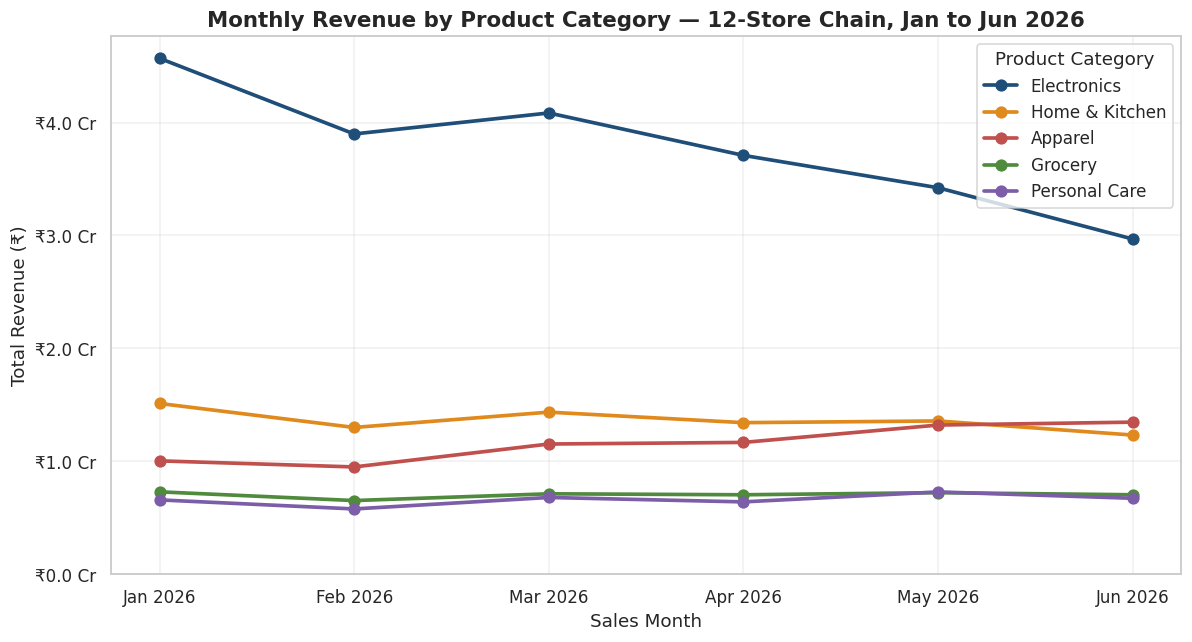

In [11]:
MONTH_ORDER = [p.strftime("%b %Y") for p in monthly_category.index]

fig, ax = plt.subplots()
for cat in cat_mix.index:                       # plotted largest category first
    ax.plot(MONTH_ORDER, monthly_category[cat].values,
            marker="o", linewidth=2.4, markersize=7,
            color=CATEGORY_COLOURS[cat], label=cat)

ax.set_title("Monthly Revenue by Product Category — 12-Store Chain, Jan to Jun 2026")
ax.set_xlabel("Sales Month")
ax.set_ylabel("Total Revenue (\u20b9)")
rupee_axis(ax, scale=1e7, suffix=" Cr", decimals=1)
ax.set_ylim(bottom=0)
ax.legend(title="Product Category", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

In [12]:
# --- Overall change across the six months, calculated, not eyeballed ---
first_month, last_month = monthly_category.index[0], monthly_category.index[-1]

trend = pd.DataFrame({
    "Jan 2026 revenue": monthly_category.loc[first_month],
    "Jun 2026 revenue": monthly_category.loc[last_month],
})
trend["Change (\u20b9)"] = trend["Jun 2026 revenue"] - trend["Jan 2026 revenue"]
trend["Change %"] = (trend["Change (\u20b9)"] / trend["Jan 2026 revenue"] * 100).round(2)
trend = trend.sort_values("Change %")

print("CATEGORY-LEVEL CHANGE, JANUARY vs JUNE 2026")
trend.round(2)

CATEGORY-LEVEL CHANGE, JANUARY vs JUNE 2026


,Jan 2026 revenue,Jun 2026 revenue,Change (₹),Change %
category,,,,
Electronics,45686596.63,29686824.81,-15999771.82,-35.02
Home & Kitchen,15130871.54,12333283.07,-2797588.47,-18.49
Grocery,7307011.34,7047719.23,-259292.11,-3.55
Personal Care,6593734.81,6737354.12,143619.31,2.18
Apparel,10049916.78,13476952.88,3427036.10,34.10


In [13]:
# --- Month-over-month movement and consistency ---
mom = (monthly_category.pct_change() * 100).round(2)
print("MONTH-OVER-MONTH REVENUE CHANGE (%)")
print(mom.to_string())

consistency = pd.DataFrame({
    "Mean monthly revenue": monthly_category.mean(),
    "Std dev of monthly revenue": monthly_category.std(),
})
consistency["Coefficient of variation %"] = (
    consistency["Std dev of monthly revenue"] / consistency["Mean monthly revenue"] * 100).round(2)
consistency["Months of decline (of 5)"] = (mom < 0).sum()
consistency["Jan-Jun change %"] = trend["Change %"]
consistency = consistency.sort_values("Coefficient of variation %")

print("\nCONSISTENCY OF EACH CATEGORY (lower coefficient of variation = steadier)")
print(consistency.round(2).to_string())

print("\nSteepest decline   :", trend.index[0],
      f"({trend['Change %'].iloc[0]:+.2f}%, {inr(trend['Change (\u20b9)'].iloc[0])})")
print("Most consistent    :", consistency.index[0],
      f"(CV {consistency['Coefficient of variation %'].iloc[0]:.2f}%, "
      f"Jan-Jun {consistency['Jan-Jun change %'].iloc[0]:+.2f}%)")
print("Strongest growth   :", trend.index[-1],
      f"({trend['Change %'].iloc[-1]:+.2f}%, {inr(trend['Change (\u20b9)'].iloc[-1])})")

MONTH-OVER-MONTH REVENUE CHANGE (%)
category  Apparel  Electronics  Grocery  Home & Kitchen  Personal Care
month                                                                 
2026-01       NaN          NaN      NaN             NaN            NaN
2026-02     -5.36       -14.66   -10.57          -14.04         -12.15
2026-03     21.34         4.77     9.15           10.42          17.53
2026-04      1.22        -9.19    -1.20           -6.48          -5.73
2026-05     13.16        -7.72     2.63            1.12          13.73
2026-06      1.95       -13.26    -2.56           -9.19          -7.69

CONSISTENCY OF EACH CATEGORY (lower coefficient of variation = steadier)
                Mean monthly revenue  Std dev of monthly revenue  Coefficient of variation %  Months of decline (of 5)  Jan-Jun change %
category                                                                                                                                
Grocery                   7050430.13            

In [14]:
# --- Control for unequal month lengths (February has 28 days) before drawing conclusions ---
days_in_month = df.groupby("month")["date"].nunique()
avg_daily = monthly_category.div(days_in_month, axis=0)

print("TRADING DAYS PER MONTH")
print(days_in_month.to_string())

print("\nAVERAGE DAILY REVENUE BY CATEGORY (\u20b9 Lakh) - removes the February length effect")
print((avg_daily / 1e5).round(2).to_string())

daily_change = ((avg_daily.iloc[-1] - avg_daily.iloc[0]) / avg_daily.iloc[0] * 100).round(2)
print("\nJan-Jun change on an average-daily basis (%):")
print(daily_change.sort_values().to_string())

TRADING DAYS PER MONTH
month
2026-01    31
2026-02    28
2026-03    31
2026-04    30
2026-05    31
2026-06    30
Freq: M

AVERAGE DAILY REVENUE BY CATEGORY (₹ Lakh) - removes the February length effect
category  Apparel  Electronics  Grocery  Home & Kitchen  Personal Care
month                                                                 
2026-01      3.24        14.74     2.36            4.88           2.13
2026-02      3.40        13.92     2.33            4.65           2.07
2026-03      3.72        13.18     2.30            4.63           2.20
2026-04      3.89        12.36     2.35            4.48           2.14
2026-05      4.26        11.04     2.33            4.38           2.35
2026-06      4.49         9.90     2.35            4.11           2.25

Jan-Jun change on an average-daily basis (%):
category
Electronics      -32.85
Home & Kitchen   -15.77
Grocery           -0.33
Personal Care      5.58
Apparel           38.57


### What this means for the supplier review — Geetha

**What happened.** Electronics fell from **₹4.57 Cr in January to ₹2.97 Cr in June — a 35.02% decline,
₹1.60 Cr of revenue gone** — and it is the only category that declined in four of its five
month-over-month steps. The decline is not a February calendar artefact: on an average-daily basis,
which removes February's shorter month, Electronics still falls **32.85%**. Over the same window
**Apparel grew 34.10% (₹1.00 Cr → ₹1.35 Cr, +₹34.27 L)**, rising in every month except February.
**Grocery is the most consistent performer** with a coefficient of variation of just **3.87%** across
the six months and an effectively flat Jan–Jun position (−3.55%); Personal Care was broadly stable at
+2.18%, and Home & Kitchen slipped 18.49%.

**Why it matters to the Category Manager.** Electronics is 49.3% of chain revenue, so its slide *is*
the chain's slide — total monthly revenue fell from ₹8.48 Cr in January to ₹6.93 Cr in June, a loss of
₹1.55 Cr. Electronics alone lost ₹1.60 Cr, meaning it lost *more* than the whole chain did and growth
elsewhere (principally Apparel) absorbed the difference. The supplier presenting Electronics will almost
certainly point to being the largest category by revenue. Size is not the question; direction is. A
supplier holding half the chain's revenue and losing a third of it in six months is asking the chain
to fund a declining asset, and the trend line is the evidence that reframes that conversation.

**What action this suggests.**
- **Electronics — challenge, do not cut blind.** Hold the shelf space pending the Step 6.3 product
  drill-down, but make continued promotional investment conditional on the supplier explaining the
  decline and committing to a recovery plan with a measurable June-exit run rate.
- **Apparel — back it.** It is the only category with sustained growth and it has absorbed a rising
  share of chain revenue without extra shelf space. It has the strongest evidence-based case for
  incremental space and promotional funding, taken from Electronics' promotional budget rather than
  from new spend.
- **Grocery — protect, do not promote.** Its value is stability and footfall, not growth. Promotional
  rupees spent here buy very little movement; treat it as the traffic base that supports the rest of
  the store.

---